# Level 2 - Task 3: K-Means Clustering Analysis
**Dataset:** Cleaned Boston House Price Dataset (`cleaned_house_data.xlsx`)  
**Objective:** Standardize features, determine the optimal number of clusters using the Elbow Method, apply K-Means clustering, and visualize distinct property segments using 2D scatter plots.

## 1. Importing Libraries & Loading Cleaned Data
Importing core libraries for data handling, scaling, K-Means clustering, and visualization, followed by loading our preprocessed dataset.

In [1]:
# Import necessary libraries for K-Means Clustering
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set display options
pd.set_option('display.max_columns', None)
sns.set_theme(style = 'whitegrid')

# Load the cleaned dataset from Level 1
df = pd.read_excel('cleaned_house_data.xlsx')
print('Dataset loaded successfully. Shape', df.shape)
df.head()

Dataset loaded successfully. Shape (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTATE,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## 2. Feature Standardization (Data Scaling)
Applying `StandardScaler` to ensure that all features have a mean of 0 and a variance of 1, preventing features with larger numerical scales from dominating the distance metrics in K-Means.

In [2]:
# Standardize the dataset features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Convert back to DataFrame for convenience
X_scaled_df = pd.DataFrame(X_scaled, columns = df.columns)
print('Data scaling completed successfully.')
X_scaled_df.head()

Data scaling completed successfully.


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTATE,PRICE
0,-0.419782,0.284830,-1.287909,-0.272599,-0.144217,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,0.441052,-1.075562,0.159686
1,-0.417339,-0.487722,-0.593381,-0.272599,-0.740262,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,0.441052,-0.492439,-0.101524
2,-0.417342,-0.487722,-0.593381,-0.272599,-0.740262,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,0.396427,-1.208727,1.324247
3,-0.416750,-0.487722,-1.306878,-0.272599,-0.835284,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,0.416163,-1.361517,1.182758
4,-0.412482,-0.487722,-1.306878,-0.272599,-0.835284,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,0.441052,-1.026501,1.487503


## 3. Determining Optimal Clusters via the Elbow Method
Calculating the Within-Cluster Sum of Squares (Inertia) for $K$ values ranging from 1 to 10 to identify the optimal cluster count using the visual elbow point.

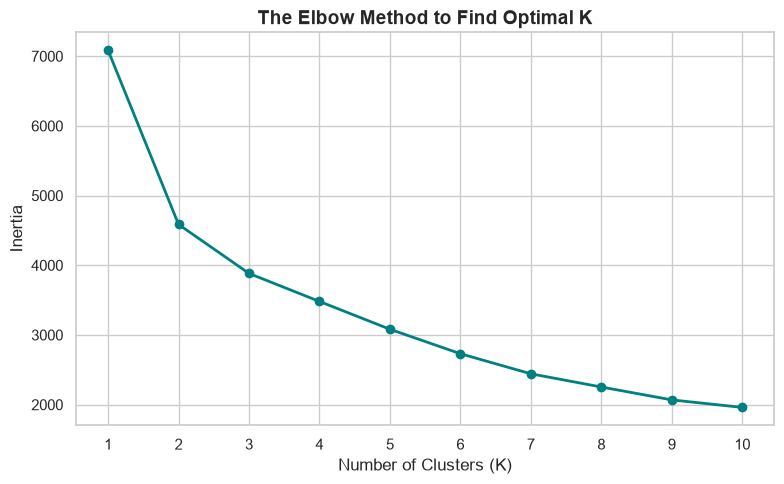

In [3]:
# Calculate Inertia fo for different values of K (from 1 to 10)
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters = k,
                    random_state = 42,
                    n_init = 10
                   )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize = (8, 5))
plt.plot(
    K_range,
    inertia,
    marker = 'o',
    color = 'teal',
    linewidth = 2,
    markersize = 6
)
plt.title(
    'The Elbow Method to Find Optimal K',
    fontsize = 14,
    fontweight = 'bold'
)
plt.xlabel('Number of Clusters (K)', fontsize = 12)
plt.ylabel('Inertia', fontsize = 12)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

## 4. Applying K-Means & 2D Cluster Visualization
Fitting the K-Means algorithm using the optimal cluster count ($K = 3$) and visualizing the segmentation using a 2D scatter plot comparing room counts (`RM`) against house prices (`PRICE`).

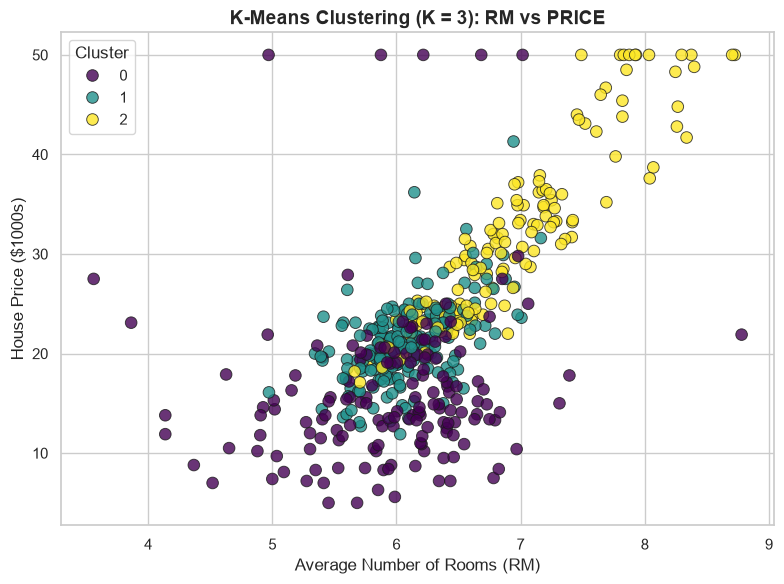

In [4]:
# Apply K-Means with the optimal K (e.g., K = 3)
optimal_k = 3
kmeans = KMeans(n_clusters = optimal_k,
               random_state = 42,
               n_init = 10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df['Cluster'] = clusters

# Visualize the clusters using two key features (e.g., RM vs PRICE) in a 2D scatter plot
plt.figure(figsize = (8, 6))
sns.scatterplot(
    data = df,
    x = 'RM',
    y = "PRICE",
    hue = 'Cluster',
    palette = 'viridis',
    s = 70,
    alpha = 0.8,
    edgecolor = 'k'
)
plt.title(
    f'K-Means Clustering (K = {optimal_k}): RM vs PRICE',
    fontsize = 14,
    fontweight = 'bold'
)
plt.xlabel('Average Number of Rooms (RM)', fontsize = 12)
plt.ylabel('House Price ($1000s)', fontsize = 12)
plt.legend(title = 'Cluster')
plt.tight_layout()
plt.show()

## 📊 Task 3 - K-Means Clustering Analytical Insights

1. **Feature Standardization:** - Applied `StandardScaler` prior to clustering to ensure equal weight distribution across all features, eliminating scale bias.
2. **Optimal Clusters (Elbow Method):** - The Elbow curve effectively highlighted the optimal number of clusters, grouping the housing data into distinct socio-economic and structural segments.
3. **Cluster Behavioral Patterns:** - The 2D scatter plot between rooms (`RM`) and house prices (`PRICE`) demonstrates how K-Means successfully segments properties into lower, middle, and upper-tier clusters based on property size and valuation.